<a href="https://colab.research.google.com/github/KaiqueKai/CP1_Equipe-Lua-Foguete-e-Log-stica/blob/main/Sprint_3_MLAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Lucas Barros - Rm 571528
# Renan Eskilldsen - Rm 571097
# André Debiazzi Baldi Negrini - Rm 569062
# Kaique da Silva Assis - Rm 572718
# Vinicius Cristal de Oliveira - Rm 572049

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Leitura e tipagem
df = pd.read_csv("consumo.csv", sep=";")
df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")

print("Dimensões (linhas, colunas):", df.shape)
print("Período:", df["data"].min().date(), "a", df["data"].max().date())
print("Valores ausentes:", int(df.isna().sum().sum()))
print()
print(df.head())
print()
print(df.drop(columns="data").describe().round(2))

Dimensões (linhas, colunas): (365, 7)
Período: 2015-01-01 a 2015-12-31
Valores ausentes: 0

        data  temp_media  temp_min  temp_max  chuva  fds  consumo
0 2015-01-01       27.30      23.9      32.5    0.0    0    25461
1 2015-01-02       27.02      24.5      33.5    0.0    0    28972
2 2015-01-03       24.82      22.4      29.9    0.0    1    30814
3 2015-01-04       23.98      21.5      28.6    1.2    1    29799
4 2015-01-05       23.82      21.0      28.3    0.0    0    28900

       temp_media  temp_min  temp_max   chuva     fds   consumo
count      365.00    365.00    365.00  365.00  365.00    365.00
mean        21.23     17.46     26.61    5.20    0.28  25401.37
std          3.18      2.83      4.32   12.42    0.45   4399.14
min         12.90     10.60     14.50    0.00    0.00  14343.00
25%         19.02     15.30     23.80    0.00    0.00  22008.00
50%         21.38     17.90     26.90    0.00    0.00  24867.00
75%         23.28     19.60     29.40    3.20    1.00  28631.00

In [ ]:
# Probabilidade | Classificação |
# |---|---|
# | p < 10% | Raro |
# | 10% ≤ p < 40% | Pouco provável |
# | 40% ≤ p < 90% | Provável |
# | p ≥ 90% | Quase certo |

LIMITES = [(0.10, "Raro"), (0.40, "Pouco provável"), (0.90, "Provável")]

def classificar_evento(p):
    # Classifica um evento de acordo com a probabilidade p (entre 0 e 1)
    for limite, rotulo in LIMITES:
        if p < limite:
            return rotulo
    return "Quase certo"

variavel = "consumo"
x = df[variavel]
n = len(x)


In [ ]:
# Calculo da mediana

mediana = x.median()
mediana_manual = np.sort(x.values)[n // 2]          # valor central (n ímpar)
assert mediana == mediana_manual, "Mediana inconsistente"

# b) Probabilidade de estar acima da mediana
n_acima = int((x > mediana).sum())
n_igual = int((x == mediana).sum())
n_abaixo = int((x < mediana).sum())
p_acima = n_acima / n

In [ ]:
# Classificação da mediana entre os dias acima da mediana, iguais e abaixo dela

classe_q1 = classificar_evento(p_acima)

print(f"Mediana de '{variavel}': {mediana:.0f}  (conferência manual: {mediana_manual:.0f})")
print(f"Dias acima da mediana : {n_acima}")
print(f"Dias iguais à mediana : {n_igual}")
print(f"Dias abaixo da mediana: {n_abaixo}")
print(f"P(X > mediana) = {n_acima}/{n} = {p_acima:.4f} = {p_acima:.2%}")
print(f"Classificação: {classe_q1}")

Mediana de 'consumo': 24867  (conferência manual: 24867)
Dias acima da mediana : 182
Dias iguais à mediana : 1
Dias abaixo da mediana: 182
P(X > mediana) = 182/365 = 0.4986 = 49.86%
Classificação: Provável


In [ ]:
# Diagnóstico de normalidade (apoia o uso do modelo Normal)

print(f"Assimetria (skew): {x.skew():.2f} | Curtose (excesso): {x.kurt():.2f}")
w, p_sw = stats.shapiro(x)
print(f"Shapiro-Wilk: W = {w:.4f}, p-valor = {p_sw:.4f}")

Assimetria (skew): 0.27 | Curtose (excesso): -0.40
Shapiro-Wilk: W = 0.9886, p-valor = 0.0058


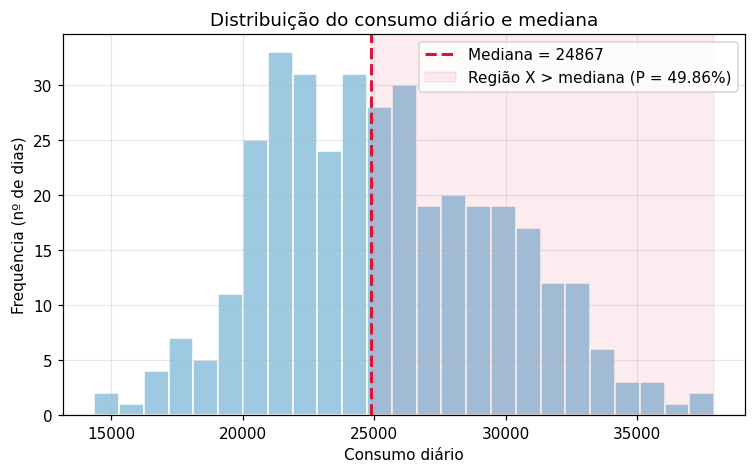

In [ ]:


fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(x, bins=25, color="#9ecae1", edgecolor="white")
ax.axvline(mediana, color="crimson", linestyle="--", linewidth=2, label=f"Mediana = {mediana:.0f}")
ax.axvspan(mediana, x.max(), color="crimson", alpha=0.08,
           label=f"Região X > mediana (P = {p_acima:.2%})")
ax.set_title("Distribuição do consumo diário e mediana")
ax.set_xlabel("Consumo diário")
ax.set_ylabel("Frequência (nº de dias)")
ax.legend()
plt.show()

In [ ]:
corr = df.drop(columns="data").corr()["consumo"].drop("consumo").sort_values(ascending=False)
print("Correlação de Pearson com 'consumo':")
print(corr.round(3))

Correlação de Pearson com 'consumo':
temp_max      0.643
temp_media    0.575
fds           0.506
temp_min      0.393
chuva        -0.194
Name: consumo, dtype: float64


In [ ]:
X = df[["temp_max"]]      # variável explicativa (matriz 2D, como exige o scikit-learn)
y = df["consumo"]         # variável resposta

modelo = LinearRegression().fit(X, y)
b0 = modelo.intercept_
b1 = modelo.coef_[0]
y_pred = modelo.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

In [ ]:
reg = stats.linregress(df["temp_max"], y)

print(f"Intercepto (β0): {b0:.2f}")
print(f"Coeficiente angular (β1): {b1:.2f}")
print(f"Equação: consumo = {b0:.2f} + {b1:.2f} * temp_max")
print()
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")
print(f"r (Pearson) = {reg.rvalue:.4f} | p-valor de β1 = {reg.pvalue:.2e} | erro-padrão de β1 = {reg.stderr:.2f}")
print()
print(f"Faixa observada de temp_max: {df['temp_max'].min():.1f} a {df['temp_max'].max():.1f} °C")
exemplo = pd.DataFrame({"temp_max": [20, 30]})
for t, p in zip(exemplo["temp_max"], modelo.predict(exemplo)):
    print(f"Consumo previsto para temp_max = {t} °C: {p:.0f}")

Intercepto (β0): 7974.94
Coeficiente angular (β1): 654.85
Equação: consumo = 7974.94 + 654.85 * temp_max

R²   = 0.4130
RMSE = 3365.74
r (Pearson) = 0.6427 | p-valor de β1 = 6.55e-44 | erro-padrão de β1 = 40.97

Faixa observada de temp_max: 14.5 a 36.5 °C
Consumo previsto para temp_max = 20 °C: 21072
Consumo previsto para temp_max = 30 °C: 27620


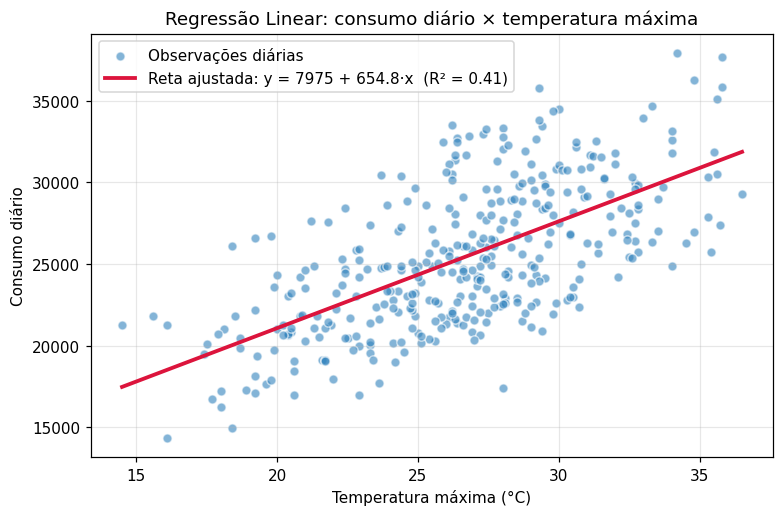

In [ ]:
x_reta = pd.DataFrame({"temp_max": np.linspace(df["temp_max"].min(), df["temp_max"].max(), 100)})
y_reta = modelo.predict(x_reta)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["temp_max"], y, alpha=0.6, color="#3182bd", edgecolor="white", label="Observações diárias")
ax.plot(x_reta["temp_max"], y_reta, color="crimson", linewidth=2.5,
        label=f"Reta ajustada: y = {b0:.0f} + {b1:.1f}·x  (R² = {r2:.2f})")
ax.set_title("Regressão Linear: consumo diário × temperatura máxima")
ax.set_xlabel("Temperatura máxima (°C)")
ax.set_ylabel("Consumo diário")
ax.legend()
plt.show()